<a href="https://www.kaggle.com/code/eymenakb/housing-prices-comp-kaggle?scriptVersionId=347429788" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Welcome

This is a step by step intermediate project using XGBoost and Optuna for Housing Prices Competition for Kaggle Learn Users.

competition: [comptetition](https://www.kaggle.com/competitions/home-data-for-ml-course/)
kaggle: [kaggle](https://www.kaggle.com/eymenakb)
github: [github](https://github.com/EymenAkb)

## Starting Installations

The installiations and descriptions are given below:

`category_encoders`: Installed for using [CatBoostEncoder](https://contrib.scikit-learn.org/category_encoders/catboost), useful categorical encoder for lots of categorical columns and values.

`optuna-integration`: Installed for integration usage [XGBoostPruningCallback](https://optuna.readthedocs.io/en/v2.0.0/reference/generated/optuna.integration.XGBoostPruningCallback). A callback method for not repeating the same results in iterations.

In [1]:
!pip install category_encoders
!pip install optuna optuna-integration scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.4/103.4 kB 4.4 MB/s eta 0:00:00


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv
/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/data_description.txt
/kaggle/input/competitions/home-data-for-ml-course/test.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv
/kaggle/input/competitions/home-data-for-ml-course/test.csv


# Start Device settings and Imports

### Adjust the code given below to match your device

In [3]:
device = "cuda"

## Importing the necessary libraries

In [4]:
import xgboost as xgb
from xgboost import XGBRegressor

import optuna
from optuna_integration import XGBoostPruningCallback

import math

import matplotlib.pyplot as plt
import seaborn as sns

from category_encoders.cat_boost import CatBoostEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import KFold

# Data Preparation

reading the csv files, fetching the columns by type, setting up the target value and removing the target from fetched column types.

In [5]:
train_df = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv", index_col=0)
test_df = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv", index_col=0)

numerical_columns = train_df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = train_df.select_dtypes(exclude=np.number).columns.tolist()

target = "SalePrice"

if target in numerical_columns:
    numerical_columns.remove(target)
if target in categorical_columns:
    categorical_columns.remove(target)

## Visualization

This is an ordinal visualization script often useful for most of the datasets, however this dataset is too long so this results might not be readable.

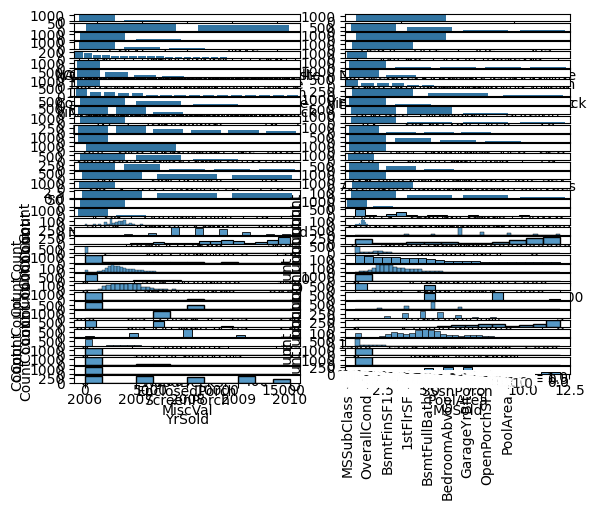

In [6]:
row_num = math.ceil((len(numerical_columns) + len(categorical_columns) + 1) / 2)
cat_len = len(categorical_columns)

fig, ax = plt.subplots(row_num, 2, squeeze=False)

axes = np.ravel(ax)

for i, column in enumerate(categorical_columns):
    value_counts = train_df[column].value_counts()
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])

for j, column in enumerate(numerical_columns):
    index_for_ax = cat_len + j
    sns.histplot(train_df[column], ax=axes[index_for_ax])

sns.heatmap(train_df[numerical_columns].corr(),annot=True, fmt=".1f")

plt.show()

# Preprocessor and training set up

Preprocessor is defined, data is transformed, and set up ready for optimizations and model.

In [7]:
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_columns),
    ("cat", CatBoostEncoder(), categorical_columns)
])

x = train_df[numerical_columns + categorical_columns]
y = train_df[target]

x_transformed = preprocessor.fit_transform(x, y)

dtrain = xgb.DMatrix(x_transformed, label=y, missing=np.nan)

# Optimization

## Defining the `objective`

Objective is the main function where optuna finds and sets up the parameters. It is based on KFold, XGBoost and PruningCallback.

In [8]:
def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "device": device,
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    
    kf = KFold(shuffle=True)
    folds = list(kf.split(x_transformed, y))

    metric_col = 'test-rmse-mean'
    pruning_callback = XGBoostPruningCallback(trial, "test-rmse")

    try:
        cv = xgb.cv(
            params=params,
            dtrain=dtrain,
            num_boost_round=1500,
            folds=folds,
            early_stopping_rounds=50,
            callbacks=[pruning_callback],
            verbose_eval=False
        )

        best_iteration = cv[metric_col].idxmin()
        optimal_n_estimators = int(best_iteration + 1)

        trial.set_user_attr("optimal_n_estimators", optimal_n_estimators)

        return cv.loc[best_iteration, metric_col]

    except optuna.exceptions.TrialPruned:
        raise

## Creating the study

Optuna runs `objective` and finds the optimal parameters based of the created study.

In [9]:
study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=100)

/tmp/ipykernel_24/2690676209.py:2: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  direction="minimize", sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
[I 2026-09-05 08:24:00,758] A new study created in memory with name: no-name-b2e7a4ab-922a-43c8-9dc8-28f2d3279ac0
[I 2026-09-05 08:24:37,297] Trial 0 finished with value: 29264.10694420361 and parameters: {'learning_rate': 0.008468008575248327, 'max_depth': 12, 'subsample': 0.8659969709057025, 'colsample_bytree': 0.7993292420985183, 'min_child_weight': 3, 'gamma': 1.7699302940633311e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893}. Best is trial 0 with value: 29264.10694420361.
[I 2026-09-05 08:24:42,641] Trial 1 finished with value: 26964.14946029416 and parameters: {'learning_rate': 0.030834348179355788, 'max_depth': 10, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'min_child_weight': 13, 'gamma'

## Setting the model parameters

Finding the optimal parameters, fetching them and setting them ready to pass into the model.

In [10]:
best_trial = study.best_trial

best_params = best_trial.params.copy()

best_params.update({
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'device': device,
    'tree_method': 'hist',
    'n_estimators': best_trial.user_attrs['optimal_n_estimators']})

# Final Model

## Setting up the `final_pipeline`

`final_pipeline` is a `Pipeline` object which uses optimal parameters found from `optuna`, sets them up into XGBRegressor, and passes the columns from preprocessor.

In [11]:
final_model = XGBRegressor(
    **best_params
)

final_pipeline = Pipeline([
    ("preprocess",preprocessor),
    ("model",final_model)
])

# Fitting the `final_pipeline`

Fitting the `final_pipeline` onto the dataset

In [12]:
final_pipeline.fit(x, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', 'GrLivArea',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'Bedroom...
                              gamma=3.982863400605158e-05, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.04975218940929533, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=5, max_leaves=None,
                              min_child_weight=9, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=682, n_jobs=None,
                              num_parallel_tree=None, ...))])

# Predicting the test results

In [13]:
x_test = test_df[numerical_columns + categorical_columns]

predictions = final_pipeline.predict(x_test)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:28:04] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


# Converting results into csv file

In [14]:
results = pd.DataFrame(
    predictions,
    index=x_test.index,
    columns=[target]
)

print(results[target].value_counts())

results.to_csv("submission.csv")

print(results.info())

SalePrice
302240.718750    2
113604.148438    1
127570.039062    1
107503.898438    1
104496.539062    1
                ..
386815.375000    1
199208.265625    1
192142.093750    1
173431.109375    1
221020.328125    1
Name: count, Length: 1458, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1459 entries, 1461 to 2919
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SalePrice  1459 non-null   float32
dtypes: float32(1)
memory usage: 17.1 KB
None


# Finding the feature importances for future usage

In [15]:
encoded_cat_names = list(final_pipeline["preprocess"].transformers_[1][1].get_feature_names_out(categorical_columns))
feature_names = numerical_columns + encoded_cat_names

importances = final_pipeline["model"].feature_importances_

print("\n--- Feature Importances ---")
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")


--- Feature Importances ---
MSSubClass: 0.0014
LotFrontage: 0.0027
LotArea: 0.0054
OverallQual: 0.1737
OverallCond: 0.0045
YearBuilt: 0.0069
YearRemodAdd: 0.0102
MasVnrArea: 0.0032
BsmtFinSF1: 0.0151
BsmtFinSF2: 0.0015
BsmtUnfSF: 0.0011
TotalBsmtSF: 0.0148
1stFlrSF: 0.0141
2ndFlrSF: 0.0106
LowQualFinSF: 0.0011
GrLivArea: 0.0492
BsmtFullBath: 0.0059
BsmtHalfBath: 0.0010
FullBath: 0.0463
HalfBath: 0.0075
BedroomAbvGr: 0.0063
KitchenAbvGr: 0.0169
TotRmsAbvGrd: 0.0177
Fireplaces: 0.0092
GarageYrBlt: 0.0017
GarageCars: 0.3727
GarageArea: 0.0101
WoodDeckSF: 0.0017
OpenPorchSF: 0.0027
EnclosedPorch: 0.0005
3SsnPorch: 0.0008
ScreenPorch: 0.0022
PoolArea: 0.0000
MiscVal: 0.0000
MoSold: 0.0006
YrSold: 0.0008
MSZoning: 0.0026
Street: 0.0009
Alley: 0.0006
LotShape: 0.0008
LandContour: 0.0022
Utilities: 0.0009
LotConfig: 0.0010
LandSlope: 0.0017
Neighborhood: 0.0437
Condition1: 0.0018
Condition2: 0.0008
BldgType: 0.0007
HouseStyle: 0.0014
RoofStyle: 0.0015
RoofMatl: 0.0014
Exterior1st: 0.0010
Exte

# This is it

The whole process of xgboost with optuna is given above, i hope you find it useful. Do not forget to upvote, for any questions and problems comment section is always there.

competition: [comptetition](https://www.kaggle.com/competitions/home-data-for-ml-course/)
kaggle: [kaggle](https://www.kaggle.com/eymenakb)
github: [github](https://github.com/EymenAkb)